## Positive Assortative Matching in Marriages in Singapore

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import re

In [2]:
r = requests.get(
    'https://data.gov.sg/api/action/datastore_search',
    params={
        'resource_id': '8a448edd-bc08-42c4-a8c4-33ecdc2398d1',
        'limit': 19999
    }
)


In [3]:
if r.status_code == 200:
    data = r.json()['result']['records']
    data = pd.DataFrame.from_records(data, index='_id')
    print(data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 408 entries, 1 to 408
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   value    408 non-null    object
 1   level_1  408 non-null    object
 2   level_2  408 non-null    object
 3   year     408 non-null    object
dtypes: object(4)
memory usage: 15.9+ KB
None


In [4]:
print(data.head(6))

     value                     level_1                     level_2  year
_id                                                                     
1    15074                       Total  Grooms - Secondary & Below  1984
2     3126                       Total     Grooms - Post-Secondary  1984
3     1772                       Total         Grooms - University  1984
4    14137  Brides - Secondary & Below  Grooms - Secondary & Below  1984
5     1966  Brides - Secondary & Below     Grooms - Post-Secondary  1984
6      561  Brides - Secondary & Below         Grooms - University  1984


In [5]:
data['year'] = pd.to_numeric(data['year'])
data['value'] = pd.to_numeric(data['value'])
data = data.rename(columns={'level_1':'brides', 'level_2':'grooms'})
data['brides'] = data['brides'].str.replace(r'^brides\W*', '', regex=True, flags=re.I)
data['grooms'] = data['grooms'].str.replace(r'^grooms\W*', '', regex=True, flags=re.I)
data = data[~data['brides'].str.contains(r'^total$', regex=True, flags=re.I)]
data = data[~data['grooms'].str.contains(r'^total$', regex=True, flags=re.I)]
data['brides'] = pd.Categorical(data['brides'], ordered=True, categories=['Secondary & Below', 'University', 'Post-Secondary'])
data['grooms'] = pd.Categorical(data['grooms'], ordered=True, categories=['Secondary & Below', 'University', 'Post-Secondary'])
data = data.pivot(index=['year','brides'], columns=['grooms'], values='value')
print(data.head(6))

grooms                  Secondary & Below  University  Post-Secondary
year brides                                                          
1984 Secondary & Below              14137         561            1966
     University                        72         743             145
     Post-Secondary                   865         468            1015
1985 Secondary & Below              12887         533            1809
     University                        81         818             154
     Post-Secondary                   832         435             946


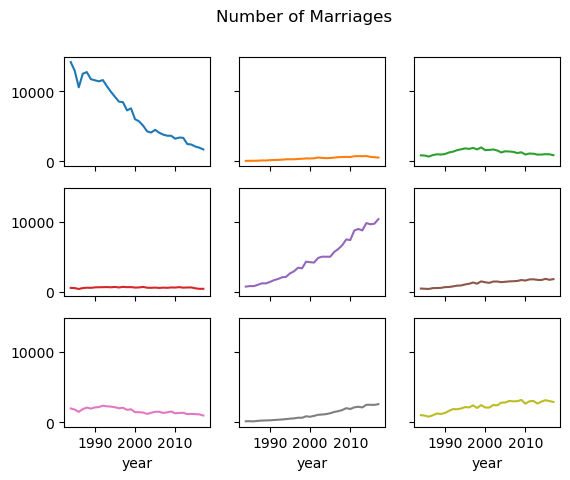

In [6]:
axs = data.unstack(level=-1).plot(subplots=True, layout=(3,3), legend=False, sharex=True, sharey=True, title='Number of Marriages')
plt.show()

In [7]:
data_props = data.groupby(level='year', group_keys=False).apply(lambda gdf: gdf / gdf.sum().sum())

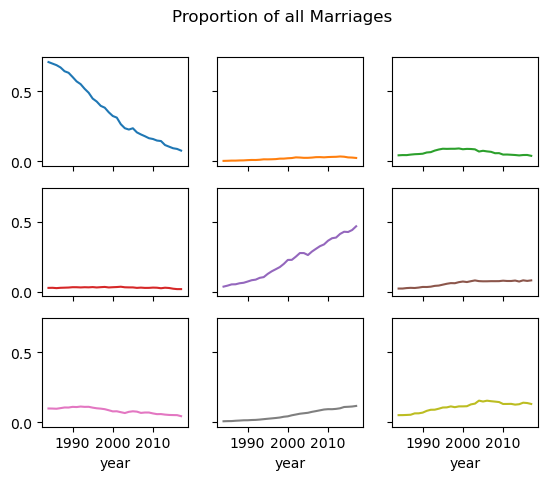

In [8]:
data_props.unstack(level=-1).plot(subplots=True, layout=(3,3), legend=False, sharex=True, sharey=True, title='Proportion of all Marriages')
plt.show()

In [9]:
def compute_iam(sorted_matrix):
    row_total = sorted_matrix.sum(axis=1)
    row_props = row_total / row_total.sum()
    col_total = sorted_matrix.sum(axis=0)
    col_props = col_total / col_total.sum()
    iam_matrix = row_props.reshape((-1,1)) @ col_props.reshape((1,-1))
    iam_matrix = iam_matrix * row_total.sum()
    iam_matrix = iam_matrix.round().astype(np.int64)
    while np.abs(iam_matrix.sum(axis=1)-row_total).sum() > 0 or np.abs(iam_matrix.sum(axis=0)-col_total).sum() > 0:
        for c in range(len(col_total)):
            for r in range(len(row_total)):
                iam_matrix[r,c] -= np.minimum(iam_matrix[:,c].sum()-col_total[c], iam_matrix[r,:].sum()-row_total[r])
    return iam_matrix

In [10]:
def compute_pam(sorted_matrix, ascending=True):
    row_total = sorted_matrix.sum(axis=1)
    col_total = sorted_matrix.sum(axis=0)
    pam_matrix = np.zeros_like(sorted_matrix)
    r = 0 if ascending else len(row_total) - 1
    c = 0 if ascending else len(col_total) - 1
    while row_total.sum() > 0 and col_total.sum() > 0:
        pam_matrix[r,c] = np.minimum(row_total[r], col_total[c])
        row_total[r] -= pam_matrix[r,c]
        col_total[c] -= pam_matrix[r,c]
        if row_total[r] == 0:
            r += 1 if ascending else -1
        if col_total[c] == 0:
            c += 1 if ascending else -1
    return pam_matrix

In [11]:
def compute_dam(sorted_matrix):
    row_total = sorted_matrix.sum(axis=1)
    col_total = sorted_matrix.sum(axis=0)
    assert (len(row_total) == len(col_total))
    dam_matrix = np.zeros_like(sorted_matrix)
    for c in range(len(col_total)):
        dam_matrix[c,c] = np.minimum(row_total[c], col_total[c])
        row_total[c] -= dam_matrix[c,c]
        col_total[c] -= dam_matrix[c,c]
    for r in range(len(row_total)):
        for c in range(len(col_total)):
            if r == c:
                continue
            else:
                dam_matrix[r,c] = np.minimum(row_total[r], col_total[c])
                row_total[r] -= dam_matrix[r,c]
                col_total[c] -= dam_matrix[r,c]
    return dam_matrix

In [12]:
data_pam = data.groupby(by='year', group_keys=False).apply(lambda gdf: pd.DataFrame(compute_pam(gdf.to_numpy(), ascending=False), index=gdf.index, columns=gdf.columns))
data_iam = data.groupby(by='year', group_keys=False).apply(lambda gdf: pd.DataFrame(compute_iam(gdf.to_numpy()), index=gdf.index, columns=gdf.columns))
data_dam = data.groupby(by='year', group_keys=False).apply(lambda gdf: pd.DataFrame(compute_dam(gdf.to_numpy()), index=gdf.index, columns=gdf.columns))

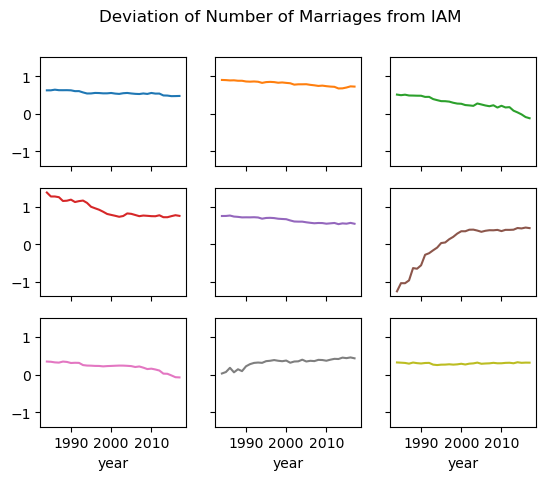

In [13]:
axs = ((data-data_iam)/(data_dam-data_iam)).unstack(level=-1).plot(subplots=True, layout=(3,3), legend=False, sharex=True, sharey=True, title='Deviation of Number of Marriages from IAM')
plt.show()

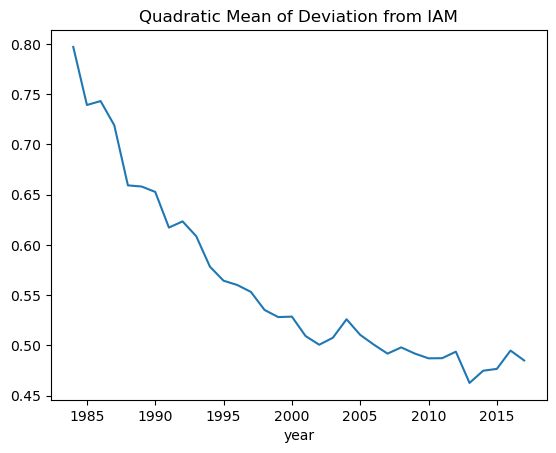

In [14]:
axs = ((data-data_iam)/(data_dam-data_iam)).unstack(level=-1).pow(2).mean(axis=1).pow(.5).plot(title='Quadratic Mean of Deviation from IAM')
plt.show()

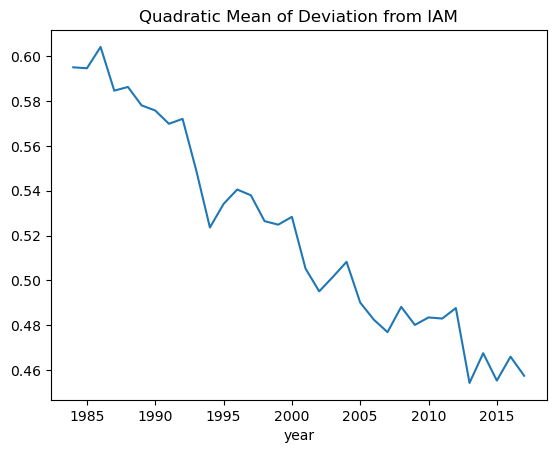

In [15]:
axs = ((data-data_iam)/(data_dam-data_iam)).unstack(level=-1).drop(columns=[c for c in data.unstack(level=-1).columns if c[0] != c[1]]).pow(2).mean(axis=1).pow(.5).plot(title='Quadratic Mean of Deviation from IAM')
plt.show()